In [320]:
from config import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
pd.set_option("display.max_columns", None)  # show all cols
pd.set_option("display.width", None)        # + better readability
from statsmodels.stats.inter_rater import aggregate_raters, fleiss_kappa
from itertools import combinations
import seaborn as sns
import re
from thefuzz import fuzz

In [321]:
raw_path = RUNS_DATA_DIR / 'raw_responses'
csv_path = RUNS_DATA_DIR / 'responses'

In [322]:
cols_to_keep = [
    'model',
    'usage'
]

In [323]:
sonnet_non_cached = pd.read_json(raw_path / '20260917-claude-sonnet-5.jsonl', lines=True)
sonnet_non_cached = sonnet_non_cached[sonnet_non_cached.batch_index == 0]
sonnet_non_cached = sonnet_non_cached[cols_to_keep]
usage_df = pd.json_normalize(sonnet_non_cached['usage'])
sonnet_non_cached = pd.concat([sonnet_non_cached.drop(columns='usage'), usage_df], axis=1)
sonnet_non_cached.head()

,model,completion_tokens,prompt_tokens,total_tokens,reasoning_tokens,cost,completion_tokens_details.accepted_prediction_tokens,completion_tokens_details.audio_tokens,completion_tokens_details.reasoning_tokens,completion_tokens_details.rejected_prediction_tokens,completion_tokens_details.text_tokens,completion_tokens_details.image_tokens,prompt_tokens_details.audio_tokens,prompt_tokens_details.cache_write_tokens,prompt_tokens_details.cached_tokens,prompt_tokens_details.image_tokens,prompt_tokens_details.text_tokens,prompt_tokens_details.video_tokens,cost_details.upstream_inference_cost,cost_details.upstream_inference_prompt_cost,cost_details.upstream_inference_completions_cost,cost_details.total_cost,cost_details.input_cost,cost_details.output_cost,cost_details.cached_input_cost,cost_details.cache_write_input_cost,cost_details.request_cost,cost_details.web_search_cost,cost_details.image_input_cost,cost_details.image_output_cost,cost_details.audio_input_cost
0,anthropic/claude-sonnet-5,6787,422164,428951,3342,1.132198,None,0,3342,None,None,0,0,0,0,0,None,0,0.912198,0.844328,0.06787,1.132198,0.844328,0.06787,0,0,0,0.22,None,None,None


In [324]:
sonnet_cache = pd.read_json(raw_path / '20260919-124908-claude-sonnet-5.jsonl', lines=True)[cols_to_keep]
usage_df = pd.json_normalize(sonnet_cache['usage'])
sonnet_cache = pd.concat([sonnet_cache.drop(columns='usage'), usage_df], axis=1)
sonnet_cache

,model,completion_tokens,prompt_tokens,total_tokens,reasoning_tokens,cost,completion_tokens_details.accepted_prediction_tokens,completion_tokens_details.audio_tokens,completion_tokens_details.reasoning_tokens,completion_tokens_details.rejected_prediction_tokens,completion_tokens_details.text_tokens,completion_tokens_details.image_tokens,prompt_tokens_details.audio_tokens,prompt_tokens_details.cache_write_tokens,prompt_tokens_details.cached_tokens,prompt_tokens_details.image_tokens,prompt_tokens_details.text_tokens,prompt_tokens_details.video_tokens,prompt_tokens_details.cache_creation_tokens,prompt_tokens_details.cache_creation.ephemeral_5m_input_tokens,prompt_tokens_details.cache_creation.ephemeral_1h_input_tokens,cost_details.upstream_inference_cost,cost_details.upstream_inference_prompt_cost,cost_details.upstream_inference_completions_cost,cost_details.total_cost,cost_details.input_cost,cost_details.output_cost,cost_details.cached_input_cost,cost_details.cache_write_input_cost,cost_details.request_cost,cost_details.web_search_cost,cost_details.image_input_cost,cost_details.image_output_cost,cost_details.audio_input_cost
0,anthropic/claude-sonnet-5,3629,450116,453745,372,0.696806,None,0,372,None,None,0,0,156617,291227,0,None,0,156617,152494,4123,0.496806,0.460516,0.03629,0.696806,0.004544,0.03629,0.058245,0.397727,0,0.2,None,None,None


In [325]:
df = pd.concat([sonnet_non_cached, sonnet_cache], keys=['non_cached', 'cached'], axis=0).droplevel(1)
df.dropna(axis='columns', how='all')

overall_cols = [
    'total_tokens', 
    'cost', #'cost_details.total_cost',     # these two are the same - use only one
    'cost_details.upstream_inference_cost',
    'prompt_tokens_details.cache_creation_tokens',
]

mapper1 = {
    'cost_details.upstream_inference_cost':'upstream_inference_cost',
    'prompt_tokens_details.cache_creation_tokens':'cache_creation_tokens',
}

detail_cols = [
    'completion_tokens',
    'prompt_tokens',
    'reasoning_tokens', # 'completions_tokens_details.reasoning_tokens', # these two are same - use only one 
    'prompt_tokens_details.cache_write_tokens',
    'prompt_tokens_details.cached_tokens',
    'cost_details.upstream_inference_prompt_cost',
    'cost_details.upstream_inference_completions_cost',
    'cost_details.input_cost',
    'cost_details.output_cost',
    'cost_details.cached_input_cost',
    'cost_details.cache_write_input_cost',
    'cost_details.web_search_cost',
    'prompt_tokens_details.cache_creation.ephemeral_5m_input_tokens',
    'prompt_tokens_details.cache_creation.ephemeral_1h_input_tokens'
]

mapper2 = {
    'prompt_tokens_details.cache_write_tokens':'cache_write_tokens',
    'prompt_tokens_details.cached_tokens':'cached_tokens',
    'cost_details.upstream_inference_prompt_cost':'upstream_inference_prompt_cost',
    'cost_details.upstream_inference_completions_cost':'upstream_inference_completions_cost',
    'cost_details.input_cost':'input_cost',
    'cost_details.output_cost':'output_cost',
    'cost_details.cached_input_cost':'cached_input_cost',
    'cost_details.cache_write_input_cost':'cache_write_input_cost',
    'cost_details.web_search_cost':'web_search_cost',
    'prompt_tokens_details.cache_creation.ephemeral_5m_input_tokens':'ephemeral_5m_input_tokens',
    'prompt_tokens_details.cache_creation.ephemeral_1h_input_tokens':'ephemeral_1h_input_tokens'
}

df_overall = df[overall_cols]
df_detailed = df[detail_cols]

df_overall = df_overall.rename(columns=mapper1)
df_detailed = df_detailed.rename(columns=mapper2)


In [326]:
df_detailed

,completion_tokens,prompt_tokens,reasoning_tokens,cache_write_tokens,cached_tokens,upstream_inference_prompt_cost,upstream_inference_completions_cost,input_cost,output_cost,cached_input_cost,cache_write_input_cost,web_search_cost,ephemeral_5m_input_tokens,ephemeral_1h_input_tokens
non_cached,6787,422164,3342,0,0,0.844328,0.06787,0.844328,0.06787,0.000000,0.000000,0.22,NaN,NaN
cached,3629,450116,372,156617,291227,0.460516,0.03629,0.004544,0.03629,0.058245,0.397727,0.20,152494.0,4123.0


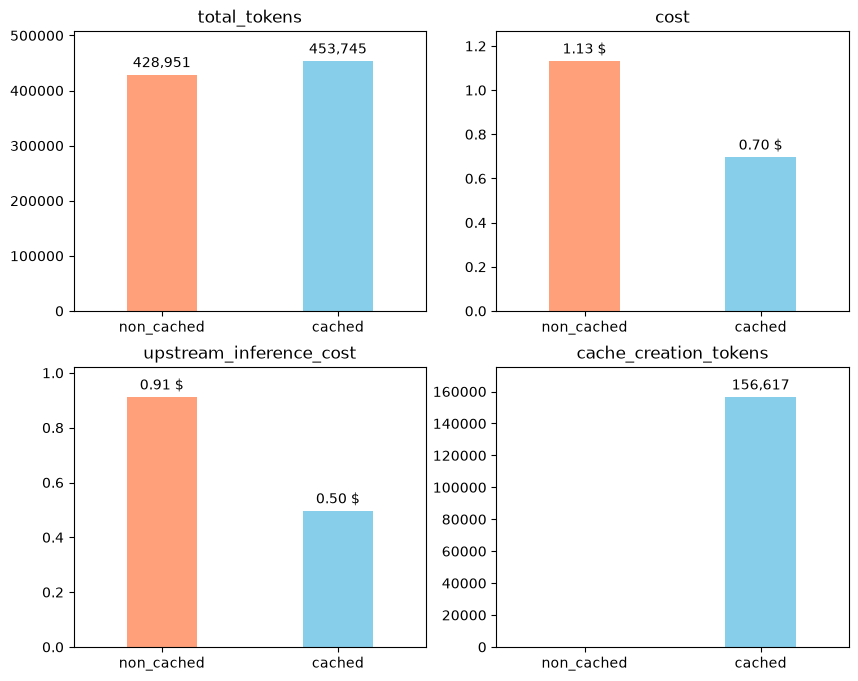

In [327]:
row_colors = {"non_cached": "lightsalmon", "cached": "skyblue"}

x = np.arange(len(df_overall.index))
labels = df_overall.index.astype(str)
colors = [row_colors[i] for i in df_overall.index]

def fmt(col, v):
    if pd.isna(v):
        return ""
    if "cost" in col.lower():
        return f"{v:,.2f} $"
    return f"{v:,.0f}"

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, col in zip(axes, df_overall.columns):
    bars = ax.bar(x, df_overall[col], width=0.4, color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlim(-0.5, len(x) - 0.5)
    ax.set_title(col)
    ax.margins(y=0.12)
    ax.bar_label(bars, labels=[fmt(col, v) for v in df_overall[col]], padding=3)

handles = [mpatches.Patch(color=c, label=l) for l, c in row_colors.items()]
plt.show()


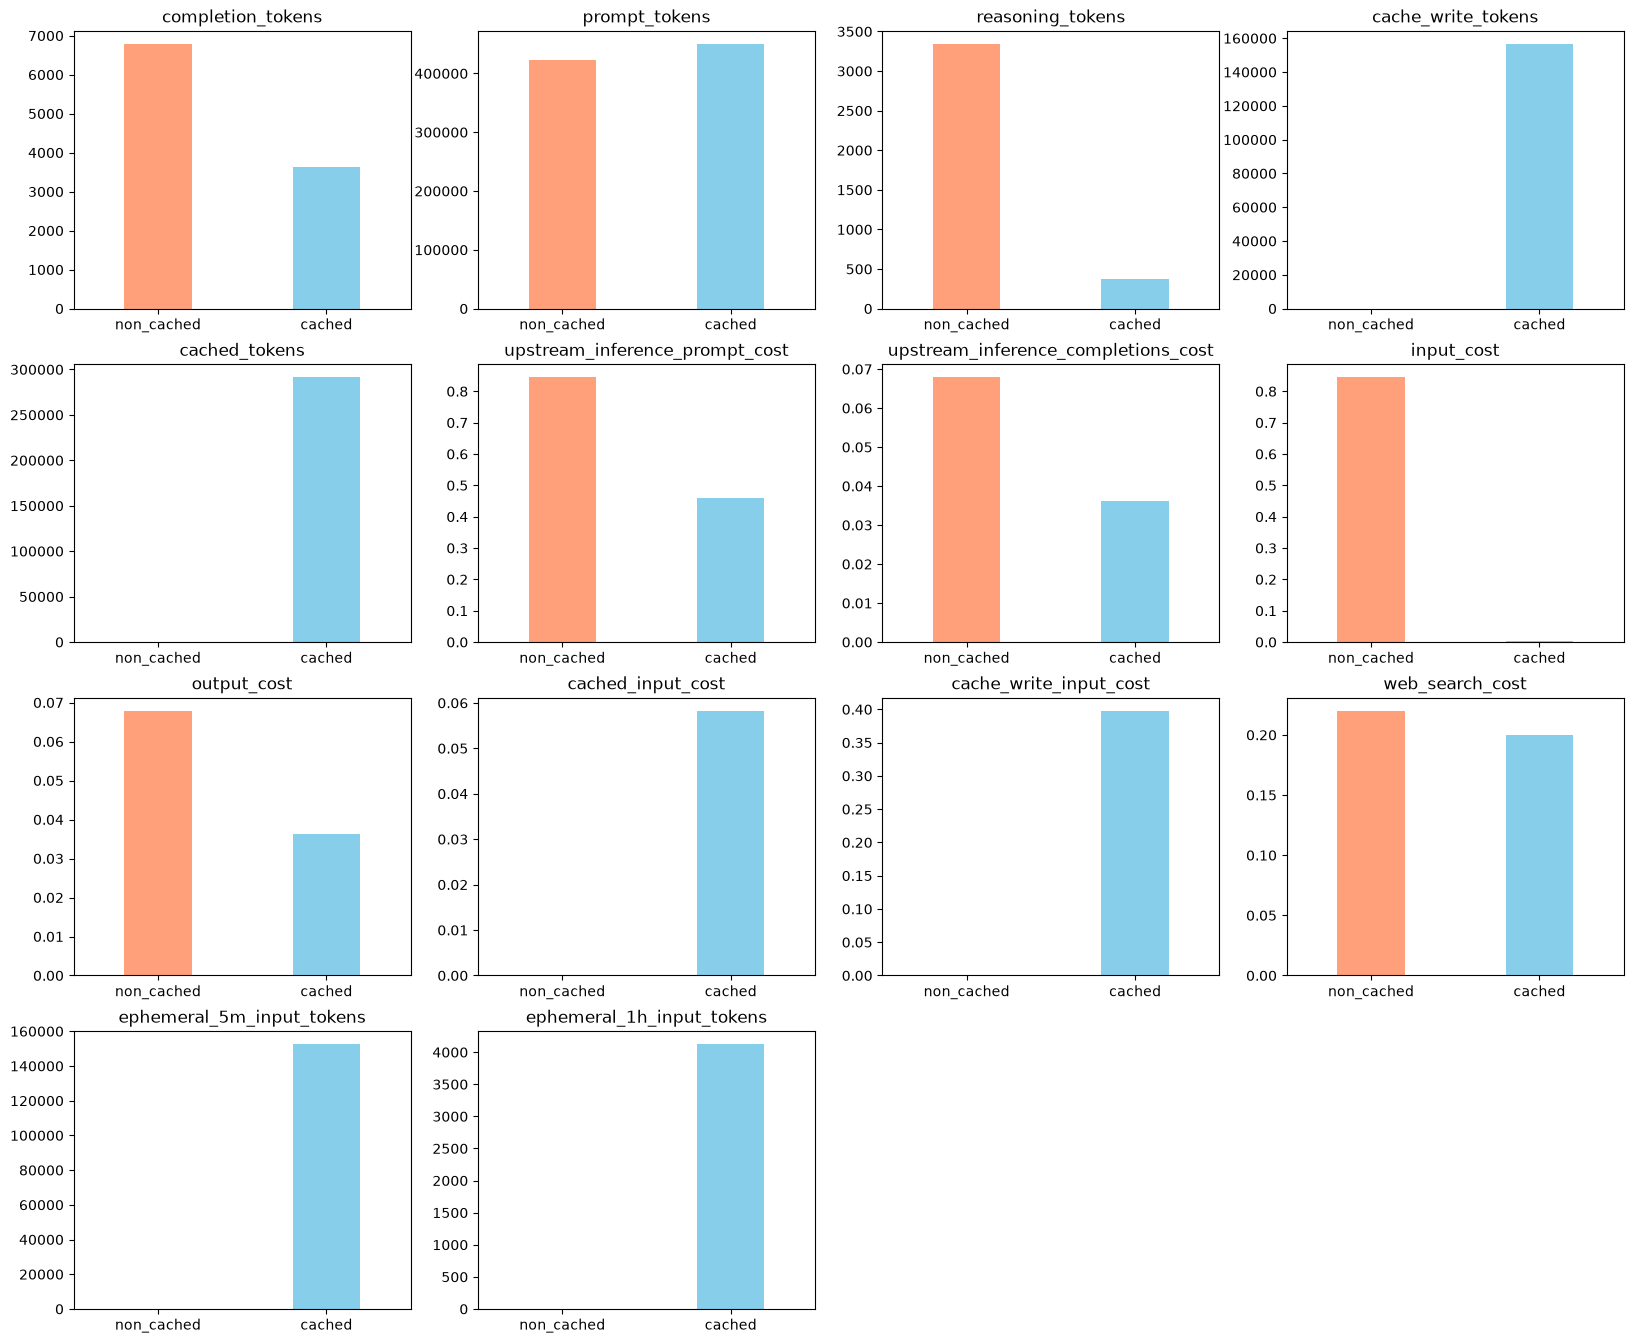

In [328]:
num_cols = df_detailed.columns
n = len(num_cols)
nrows = -(-n // 4)

x = np.arange(len(df_detailed.index))
labels = df_detailed.index.astype(str)
colors = [row_colors[i] for i in df_detailed.index]

fig, axes = plt.subplots(nrows, 4, figsize=(20, 4 * nrows + 0.6))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    ax.bar(x, df_detailed[col], width=0.4, color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlim(-0.5, len(x) - 0.5)
    ax.set_title(col)

for ax in axes[n:]:
    ax.axis("off")

handles = [mpatches.Patch(color=c, label=l) for l, c in row_colors.items()]
plt.show()


# Responses - all

In [329]:
cols_to_keep = [
    'model', 'batch_index', 'answer'
]

In [330]:
import json

files = sorted(csv_path.glob('20260917-*'))

dfs = []
for f in files:
    df = pd.read_csv(f, usecols=cols_to_keep)
    df['answer'] = df['answer'].apply(json.loads)
    df_answer = pd.json_normalize(df['answer'])
    df = df.drop(columns=['answer']).join(df_answer)
    df['model'] = df['model'].str.split('/').str[1]
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df.head()

,model,batch_index,id,name,hasFoundMenu,menuLink,format,source
0,claude-sonnet-5,0,ChIJAV1_vX1SUkYRifHQGs0-33o,Pizze Di Napo Hellerup,True,https://pizzedinapohellerup.dk/,HTML,OFFICIAL_WEBSITE
1,claude-sonnet-5,0,ChIJ7RIaXXpQUkYRxGD3xBRRltk,McDonald's,True,https://www.mcdonalds.com/dk/da-dk/vores-menu....,HTML,OFFICIAL_WEBSITE
2,claude-sonnet-5,0,ChIJq6p-9w9TUkYRGJ7PByHSDYY,Byens Pizza,True,http://byens-pizza.dk/?page_id=2065,HTML,OFFICIAL_WEBSITE
3,claude-sonnet-5,0,ChIJz3lHpeRSUkYRRNH0_-MSMhU,Restaurant Taormina v/Mukuntharaj Karunaratnam,True,https://taormina.dk/menu/,HTML,OFFICIAL_WEBSITE
4,claude-sonnet-5,0,ChIJBVGBtQFTUkYR7R1FSqjW1kg,Barnetsfest,False,,,


In [331]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1756 entries, 0 to 1755
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   model         1756 non-null   object
 1   batch_index   1756 non-null   int64 
 2   id            1756 non-null   str   
 3   name          1756 non-null   str   
 4   hasFoundMenu  1756 non-null   bool  
 5   menuLink      1756 non-null   str   
 6   format        1756 non-null   str   
 7   source        1756 non-null   str   
dtypes: bool(1), int64(1), object(1), str(5)
memory usage: 97.9+ KB


In [332]:
grouped = df.groupby('model')['hasFoundMenu'].value_counts(normalize=True).reset_index(name='pct')
grouped.head()

,model,hasFoundMenu,pct
0,claude-sonnet-5,True,0.571754
1,claude-sonnet-5,False,0.428246
2,gemini-3.7-flash,True,0.740319
3,gemini-3.7-flash,False,0.259681
4,gpt-5.6-luna,True,0.640091


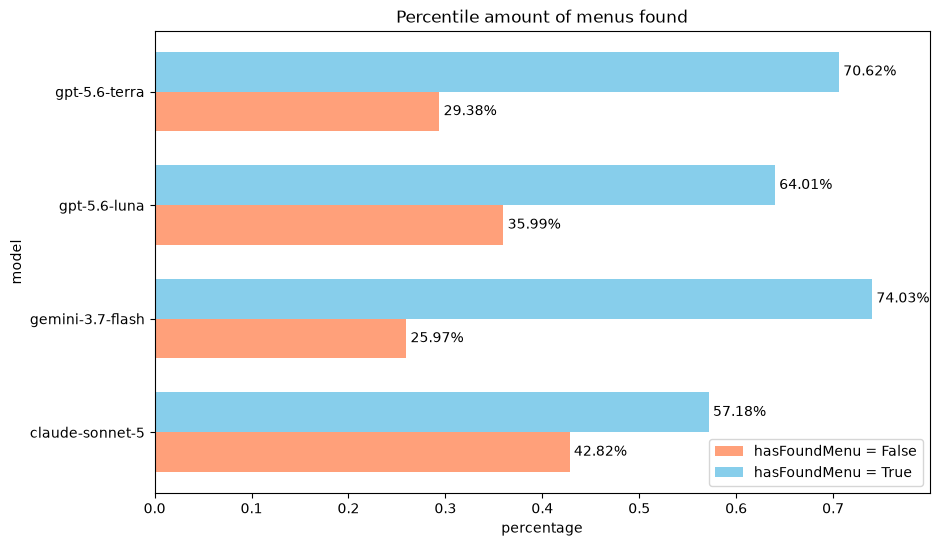

In [333]:
pivot = grouped.pivot(index='model', columns='hasFoundMenu', values='pct')

models = pivot.index
y = np.arange(len(models))
height = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars_false = ax.barh(y - height / 2, pivot[False], height=height, color='lightsalmon', label='hasFoundMenu = False')
bars_true = ax.barh(y + height / 2, pivot[True], height=height, color='skyblue', label='hasFoundMenu = True')

ax.bar_label(bars_false, fmt=lambda x: f'{x*100:.2f}%', padding=3)
ax.bar_label(bars_true, fmt=lambda x: f'{x*100:.2f}%', padding=3)

ax.set_yticks(y)
ax.set_yticklabels(models)
ax.set_xlabel('percentage')
ax.set_ylabel('model')
ax.set_title('Percentile amount of menus found')
ax.margins(x=0.08)
ax.legend(loc='lower right')
# plt.tight_layout()
plt.show()


# Model Agreement on hasFoundMenu

In [334]:
pivot_found = df.pivot_table(index='id', columns='model', values='hasFoundMenu', aggfunc='first')
pivot_found.head(10)

model,claude-sonnet-5,gemini-3.7-flash,gpt-5.6-luna,gpt-5.6-terra
id,,,,
ChIJ-7iMbc1TUkYR066Hz1SQ-EI,True,True,True,True
ChIJ-QrW55VTUkYRiO5rYIpA5PE,True,True,True,True
ChIJ-XF3Wu1TUkYRl25fQ2IL8Ps,True,True,True,True
ChIJ-YewRThSUkYRU-ZX1KiCAr0,True,True,True,True
ChIJ-ao52_ZNUkYRU11OTne3ec8,True,True,True,True
ChIJ-dcIKQ9TUkYRCnX2QWVgSG4,True,True,True,True
ChIJ-dqxj6xTUkYR6bN0GtI7dCs,True,True,True,True
ChIJ-fk2NRBTUkYRyhj40xrfESA,True,True,True,True
ChIJ-xIoQDlTUkYRQYAPd7S0xRA,True,False,False,True


In [335]:
table, categories = aggregate_raters(pivot_found.to_numpy())
kappa = fleiss_kappa(table)

print(f"Fleiss' kappa (hasFoundMenu, 4 raters): {kappa:.3f}")

Fleiss' kappa (hasFoundMenu, 4 raters): 0.538


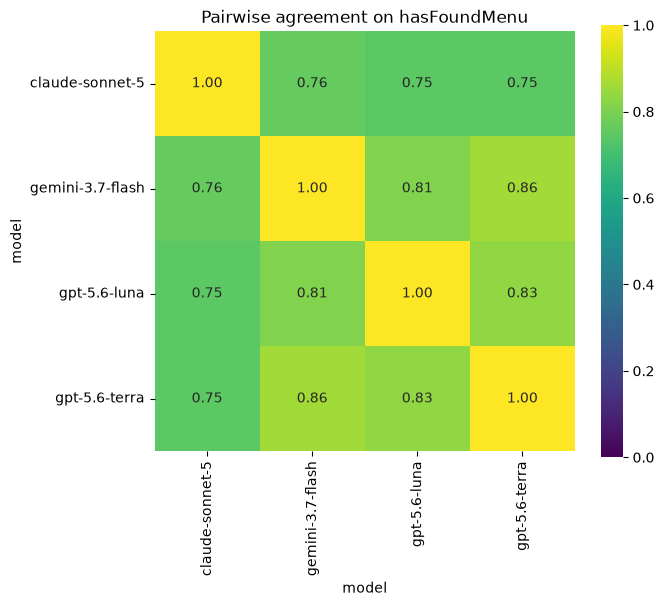

In [336]:
agreement = pd.DataFrame(np.eye(len(models)), index=models, columns=models)

for model_1, model_2 in combinations(models, 2):
    rate = (pivot_found[model_1] == pivot_found[model_2]).mean()
    agreement.loc[model_1, model_2] = rate
    agreement.loc[model_2, model_1] = rate

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(agreement, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='viridis', square=True, ax=ax)
ax.set_title('Pairwise agreement on hasFoundMenu')
plt.tight_layout()
plt.show()

# Regex Normalization of URL

- Ignoring prefix such as `http`, `https://`, `www.` etc.

In [337]:
url_prefix_pattern = re.compile(r'^(?:https?://)?(?:www\.)?', re.IGNORECASE)

df['normalized_urls'] = df['menuLink'].str.replace(url_prefix_pattern, '', regex=True)
df[['menuLink', 'normalized_urls']].head(10)
df.head()

,model,batch_index,id,name,hasFoundMenu,menuLink,format,source,normalized_urls
0,claude-sonnet-5,0,ChIJAV1_vX1SUkYRifHQGs0-33o,Pizze Di Napo Hellerup,True,https://pizzedinapohellerup.dk/,HTML,OFFICIAL_WEBSITE,pizzedinapohellerup.dk/
1,claude-sonnet-5,0,ChIJ7RIaXXpQUkYRxGD3xBRRltk,McDonald's,True,https://www.mcdonalds.com/dk/da-dk/vores-menu....,HTML,OFFICIAL_WEBSITE,mcdonalds.com/dk/da-dk/vores-menu.html
2,claude-sonnet-5,0,ChIJq6p-9w9TUkYRGJ7PByHSDYY,Byens Pizza,True,http://byens-pizza.dk/?page_id=2065,HTML,OFFICIAL_WEBSITE,byens-pizza.dk/?page_id=2065
3,claude-sonnet-5,0,ChIJz3lHpeRSUkYRRNH0_-MSMhU,Restaurant Taormina v/Mukuntharaj Karunaratnam,True,https://taormina.dk/menu/,HTML,OFFICIAL_WEBSITE,taormina.dk/menu/
4,claude-sonnet-5,0,ChIJBVGBtQFTUkYR7R1FSqjW1kg,Barnetsfest,False,,,,


In [338]:
df_menulinks = df.pivot_table(index='id', columns='model', values='normalized_urls', aggfunc='first')
df_menulinks.head(5)

model,claude-sonnet-5,gemini-3.7-flash,gpt-5.6-luna,gpt-5.6-terra
id,,,,
ChIJ-7iMbc1TUkYR066Hz1SQ-EI,restaurantalf.dk/,restaurantalf.dk/,restaurantalf.dk/,restaurantalf.dk/
ChIJ-QrW55VTUkYRiO5rYIpA5PE,durumbar-frb.dk/,durumbar78.dk/,durumbar2000.dk/,ubereats.com/dk-en/store/durum-bar-2000/KBI4og...
ChIJ-XF3Wu1TUkYRl25fQ2IL8Ps,royalbagel.dk/royal-bagel-valby-langgade/takeaway,wolt.com/da/dnk/copenhagen/restaurant/royal-ba...,wolt.com/da/dnk/copenhagen/restaurant/royal-ba...,ubereats.com/dk-en/store/royal-bagel-valby/sjJ...
ChIJ-YewRThSUkYRU-ZX1KiCAr0,nordvestpizzaria.dk/,eatonline.dk/restaurant/172/nord-vest-pizza-gr...,eatonline.dk/restaurant/172/nord-vest-pizza-gr...,eatonline.dk/restaurant/172/nord-vest-pizza-gr...
ChIJ-ao52_ZNUkYRU11OTne3ec8,joejuice.com/,joejuice.com/menu,joejuice.com/?market=dk,ubereats.com/dk-en/store/joe-%26-the-juice-gen...


In [339]:
def safe_ratio(u1, u2):
    if pd.isna(u1) or pd.isna(u2) or u1 == '' or u2 == '':
        return np.nan
    return fuzz.ratio(u1, u2)

model_url_agreement = {}

for model_1 in df_menulinks.columns:
    scores = df_menulinks[[model_1]].rename(columns={model_1: 'url'})
    
    for model_2 in df_menulinks.columns:
        if model_2 == model_1:
            continue
        scores[model_2] = [safe_ratio(u1, u2) for u1, u2 in zip(df_menulinks[model_1], df_menulinks[model_2])]
    model_url_agreement[model_1] = scores

model_url_agreement['claude-sonnet-5'].head(10)

model,url,gemini-3.7-flash,gpt-5.6-luna,gpt-5.6-terra
id,,,,
ChIJ-7iMbc1TUkYR066Hz1SQ-EI,restaurantalf.dk/,100.0,100.0,100.0
ChIJ-QrW55VTUkYRiO5rYIpA5PE,durumbar-frb.dk/,80.0,75.0,26.0
ChIJ-XF3Wu1TUkYRl25fQ2IL8Ps,royalbagel.dk/royal-bagel-valby-langgade/takeaway,44.0,44.0,46.0
ChIJ-YewRThSUkYRU-ZX1KiCAr0,nordvestpizzaria.dk/,44.0,44.0,44.0
ChIJ-ao52_ZNUkYRU11OTne3ec8,joejuice.com/,87.0,72.0,22.0
ChIJ-dcIKQ9TUkYRCnX2QWVgSG4,froekensandwich.dk/menu,77.0,90.0,90.0
ChIJ-dqxj6xTUkYR6bN0GtI7dCs,wolt.com/en/dnk/copenhagen/restaurant/drm-symf...,82.0,30.0,30.0
ChIJ-fk2NRBTUkYRyhj40xrfESA,aterre.dk/menuer,77.0,47.0,28.0
ChIJ-xIoQDlTUkYRQYAPd7S0xRA,lunacafe.dk/menu/,NaN,NaN,55.0


In [340]:
model_names = list(model_url_agreement.keys())
# initialize empty DF matrix
pairwise_mean_agreement = pd.DataFrame(index=model_names, columns=model_names, dtype=float)

for model_1, scores in model_url_agreement.items():
    for model_2 in scores.columns:
        # first column is the 'url', so we just skip it (not needed)
        if model_2 == 'url':
            continue
        # otherwise calculate the mean of model_1's agreement with the model_2
        pairwise_mean_agreement.loc[model_1, model_2] = scores[model_2].mean()

pairwise_mean_agreement

,claude-sonnet-5,gemini-3.7-flash,gpt-5.6-luna,gpt-5.6-terra
claude-sonnet-5,NaN,68.279661,66.412322,66.746667
gemini-3.7-flash,68.279661,NaN,66.252874,64.261324
gpt-5.6-luna,66.412322,66.252874,NaN,76.424710
gpt-5.6-terra,66.746667,64.261324,76.424710,NaN


In [341]:
pairwise_mean_agreement = pairwise_mean_agreement.fillna(100)
pairwise_mean_agreement


,claude-sonnet-5,gemini-3.7-flash,gpt-5.6-luna,gpt-5.6-terra
claude-sonnet-5,100.000000,68.279661,66.412322,66.746667
gemini-3.7-flash,68.279661,100.000000,66.252874,64.261324
gpt-5.6-luna,66.412322,66.252874,100.000000,76.424710
gpt-5.6-terra,66.746667,64.261324,76.424710,100.000000


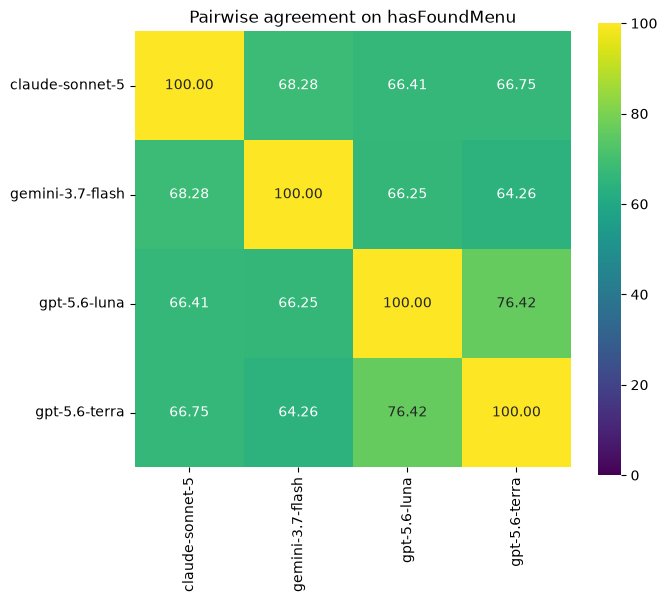

In [342]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(pairwise_mean_agreement, annot=True, fmt='.2f', vmin=0, vmax=100, cmap='viridis', square=True, ax=ax)
ax.set_title('Pairwise agreement on hasFoundMenu')
plt.tight_layout()
plt.show()